# 02.5 - Probability

**Phase:** 02 - Mathematics for ML

**Status:** VERIFIED

---

## 1. What Are We Solving?

Machine learning is full of **uncertainty**: data is noisy, models make probabilistic predictions, and we reason about what is likely. **Probability** is the mathematical language of uncertainty. It underpins loss functions (cross-entropy), model evaluation, Bayesian methods, and generative models.

## 2. Why Does This Matter?

Almost every ML concept builds on probability: maximum likelihood estimation, Naive Bayes, logistic regression, hidden Markov models, and the entire field of probabilistic deep learning. Understanding probability lets you reason rigorously about what your model is actually doing.

## 3. Prerequisites

- Unit 02.1 (Vectors & matrices)
- Unit 02.2 (Matrix operations)

## 4. Learning Objectives

By the end of this notebook, you should be able to:
- Define probability, sample spaces, and events
- Compute conditional probability and use Bayes' theorem
- Understand independence and the chain rule
- Work with random variables and probability distributions
- Understand expectation and variance
- Use the normal (Gaussian) distribution

## 5. Mental Model

Probability assigns a number between 0 and 1 to how likely an event is. **Conditional probability** `P(A|B)` asks: given that B happened, how likely is A? **Bayes' theorem** flips conditional probabilities around - it's the foundation of updating beliefs with evidence. **Random variables** map outcomes to numbers, and **distributions** describe how likely each value is.


## 6. Basic Probability

A **sample space** is the set of all possible outcomes. An **event** is a subset of outcomes. The probability of an event is the number of favorable outcomes divided by the total number of outcomes (for equally likely outcomes).

Let's simulate a fair coin and a fair die.


Simulated P(Heads) over 100000 flips: 0.4994 (expected 0.5)
Simulated P(even roll) over 100000 rolls: 0.4992 (expected 0.5)


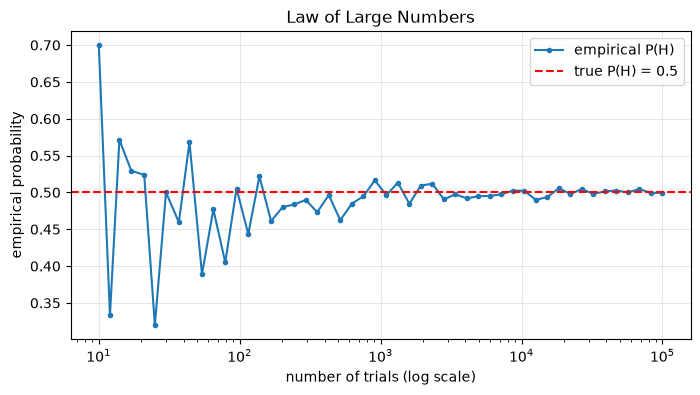

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate a fair coin: P(Heads) = 0.5
np.random.seed(42)
n = 100000
flips = np.random.choice(["H", "T"], size=n)
p_heads = np.mean(flips == "H")
print(f"Simulated P(Heads) over {n} flips: {p_heads:.4f} (expected 0.5)")

# Simulate a fair die: P(even) = 3/6 = 0.5
rolls = np.random.randint(1, 7, size=n)
p_even = np.mean(rolls % 2 == 0)
print(f"Simulated P(even roll) over {n} rolls: {p_even:.4f} (expected 0.5)")

# Law of large numbers: as n grows, empirical probability approaches true probability
ns = np.logspace(1, 5, 50).astype(int)
empirical = [np.mean(np.random.choice(["H", "T"], size=k) == "H") for k in ns]
plt.figure(figsize=(8, 4))
plt.plot(ns, empirical, marker="o", markersize=3, label="empirical P(H)")
plt.axhline(0.5, color="red", linestyle="--", label="true P(H) = 0.5")
plt.xscale("log")
plt.xlabel("number of trials (log scale)")
plt.ylabel("empirical probability")
plt.title("Law of Large Numbers")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 7. Conditional Probability

The **conditional probability** of A given B is:

`P(A|B) = P(A and B) / P(B)`

It asks: among the outcomes where B happened, what fraction also have A?

Let's use a concrete example: a deck of cards. What is P(face card | red card)?


In [2]:
# Conditional probability with a deck of cards
# 52 cards: 26 red, 26 black; 12 face cards (J,Q,K) total, 6 red face cards
total = 52
red = 26
red_face = 6  # J,Q,K of hearts + J,Q,K of diamonds

p_red = red / total
p_red_face = red_face / total
p_face_given_red = p_red_face / p_red

print(f"P(red) = {p_red:.4f}")
print(f"P(red AND face) = {p_red_face:.4f}")
print(f"P(face | red) = {p_face_given_red:.4f} (expected 6/26 = {6/26:.4f})")

# Verify by simulation
np.random.seed(1)
n = 200000
colors = np.random.choice(["red", "black"], size=n, p=[0.5, 0.5])
# Among red cards, 6/26 are face cards
is_face = np.where(colors == "red", np.random.rand(n) < 6/26, False)
red_mask = colors == "red"
sim = np.mean(is_face[red_mask])
print(f"Simulated P(face | red): {sim:.4f}")


P(red) = 0.5000
P(red AND face) = 0.1154
P(face | red) = 0.2308 (expected 6/26 = 0.2308)
Simulated P(face | red): 0.2304


## 8. Bayes' Theorem

**Bayes' theorem** lets us flip a conditional probability:

`P(A|B) = P(B|A) * P(A) / P(B)`

This is the foundation of **Bayesian inference** - updating our belief `P(A)` (the prior) into `P(A|B)` (the posterior) after seeing evidence B.

Classic example: a medical test. Suppose a disease affects 1% of people, the test is 99% accurate (sensitivity and specificity 0.99). If someone tests positive, what's the probability they actually have the disease?


In [3]:
# Bayes' theorem: medical test example
# P(disease) = 0.01 (prior)
# P(positive | disease) = 0.99 (sensitivity)
# P(positive | no disease) = 0.01 (false positive rate)
p_disease = 0.01
p_pos_given_disease = 0.99
p_pos_given_healthy = 0.01

# P(positive) = P(pos|disease)*P(disease) + P(pos|healthy)*P(healthy)
p_positive = p_pos_given_disease * p_disease + p_pos_given_healthy * (1 - p_disease)

# P(disease | positive) = P(pos|disease)*P(disease) / P(positive)
p_disease_given_positive = p_pos_given_disease * p_disease / p_positive

print(f"P(disease) = {p_disease}")
print(f"P(positive) = {p_positive:.4f}")
print(f"P(disease | positive) = {p_disease_given_positive:.4f}")
print("\nSurprising result: even with a 99% accurate test, a positive result")
print("means only ~50% chance of disease, because the disease is rare.")


P(disease) = 0.01
P(positive) = 0.0198
P(disease | positive) = 0.5000

Surprising result: even with a 99% accurate test, a positive result
means only ~50% chance of disease, because the disease is rare.


## 9. Independence

Two events A and B are **independent** if `P(A and B) = P(A) * P(B)`, equivalently `P(A|B) = P(A)`. Knowing B tells you nothing about A.

The **chain rule** generalizes the product rule to many events:

`P(A, B, C) = P(A) * P(B|A) * P(C|A, B)`

This is the basis of **Naive Bayes**, which assumes features are conditionally independent.


In [4]:
# Independence: coin flips are independent
np.random.seed(3)
n = 100000
flip1 = np.random.rand(n) < 0.5
flip2 = np.random.rand(n) < 0.5

p_both = np.mean(flip1 & flip2)
p1 = np.mean(flip1)
p2 = np.mean(flip2)
print(f"P(H1 and H2) = {p_both:.4f}")
print(f"P(H1)*P(H2) = {p1*p2:.4f}")
print(f"Independent (equal): {abs(p_both - p1*p2) < 0.01}")

# Chain rule for 3 independent coin flips
p_3heads = np.mean(flip1 & flip2 & (np.random.rand(n) < 0.5))
print(f"P(3 heads) = {p_3heads:.4f} (expected 0.125)")


P(H1 and H2) = 0.2492
P(H1)*P(H2) = 0.2502
Independent (equal): True
P(3 heads) = 0.1250 (expected 0.125)


## 10. Random Variables and Distributions

A **random variable** maps outcomes to numbers. Its **distribution** describes the probability of each value.

- **Discrete**: e.g. Bernoulli (coin), Binomial (number of heads), Poisson (counts).
- **Continuous**: e.g. Uniform, Normal (Gaussian), Exponential.

Let's explore the **Binomial** distribution: number of heads in `n` independent coin flips.


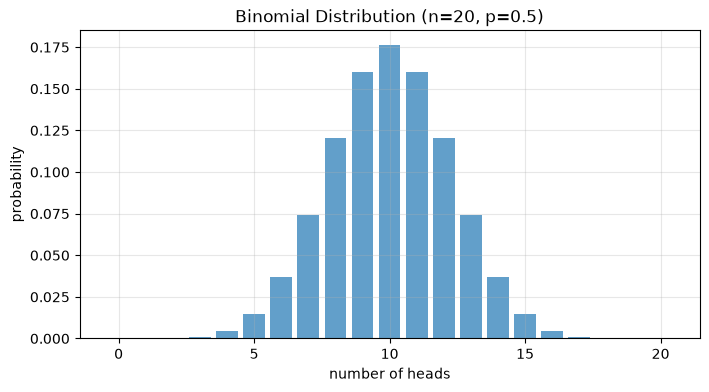

Most likely outcome: 10 heads
Expected value (mean): 10.0
Variance: 5.0


In [5]:
# Binomial distribution: number of heads in n flips
from scipy import stats

n_flips = 20
p = 0.5
k = np.arange(0, n_flips + 1)
pmf = stats.binom.pmf(k, n_flips, p)

plt.figure(figsize=(8, 4))
plt.bar(k, pmf, width=0.8, alpha=0.7)
plt.xlabel("number of heads")
plt.ylabel("probability")
plt.title(f"Binomial Distribution (n={n_flips}, p={p})")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Most likely outcome: {np.argmax(pmf)} heads")
print(f"Expected value (mean): {n_flips * p}")
print(f"Variance: {n_flips * p * (1 - p)}")


## 11. Expectation and Variance

- **Expectation** `E[X]` is the average value of a random variable - the center of the distribution.
- **Variance** `Var[X] = E[(X - E[X])^2]` measures how spread out the distribution is.
- **Standard deviation** is the square root of variance.

Let's compute these empirically and compare to theory.


In [6]:
# Expectation and variance of a Binomial
np.random.seed(5)
samples = np.random.binomial(n_flips, p, size=100000)

emp_mean = np.mean(samples)
emp_var = np.var(samples)
theo_mean = n_flips * p
theo_var = n_flips * p * (1 - p)

print(f"Empirical mean: {emp_mean:.4f} (theoretical {theo_mean})")
print(f"Empirical variance: {emp_var:.4f} (theoretical {theo_var})")
print(f"Empirical std: {np.std(samples):.4f} (theoretical {np.sqrt(theo_var):.4f})")


Empirical mean: 10.0108 (theoretical 10.0)
Empirical variance: 4.9718 (theoretical 5.0)
Empirical std: 2.2298 (theoretical 2.2361)


## 12. The Normal (Gaussian) Distribution

The **normal distribution** is the most important distribution in statistics and ML. It's defined by its mean `mu` and standard deviation `sigma`:

`f(x) = (1 / (sigma * sqrt(2*pi))) * exp(-(x - mu)^2 / (2 * sigma^2))`

The **Central Limit Theorem** says that sums of many independent random variables tend toward a normal distribution - which is why it appears everywhere.


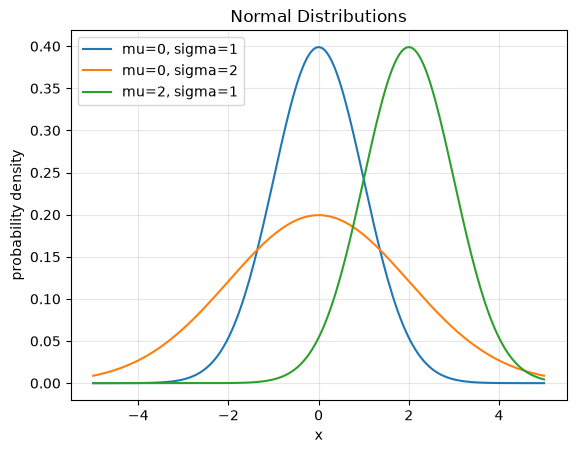

P(|x| < 1 sigma) = 0.6830 (expected ~0.68)
P(|x| < 2 sigma) = 0.9547 (expected ~0.95)


In [7]:
# The normal distribution
x = np.linspace(-5, 5, 200)
for mu, sigma in [(0, 1), (0, 2), (2, 1)]:
    pdf = stats.norm.pdf(x, mu, sigma)
    plt.plot(x, pdf, label=f"mu={mu}, sigma={sigma}")
plt.xlabel("x")
plt.ylabel("probability density")
plt.title("Normal Distributions")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Empirical rule: ~68% within 1 sigma, ~95% within 2 sigma
samples = np.random.normal(0, 1, 1000000)
p1 = np.mean(np.abs(samples) < 1)
p2 = np.mean(np.abs(samples) < 2)
print(f"P(|x| < 1 sigma) = {p1:.4f} (expected ~0.68)")
print(f"P(|x| < 2 sigma) = {p2:.4f} (expected ~0.95)")


## 13. Central Limit Theorem

The **Central Limit Theorem (CLT)** states that the distribution of the **sample mean** of many independent random variables approaches a normal distribution, regardless of the original distribution. This justifies using the normal distribution for averages.


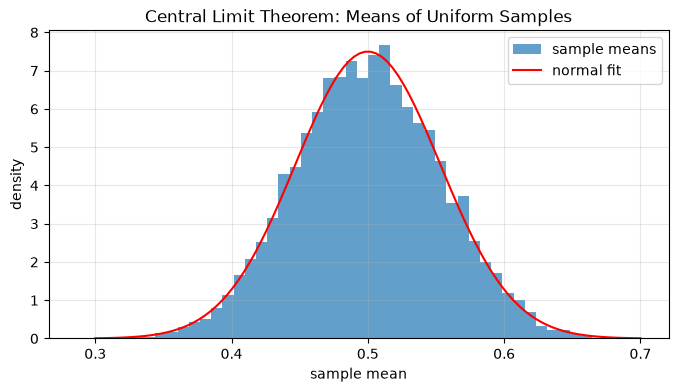

The distribution of sample means is approximately normal, even though
the underlying data is uniform - this is the Central Limit Theorem.


In [8]:
# Central Limit Theorem: means of uniform samples become normal
np.random.seed(9)
n_samples = 10000
means = []
for _ in range(n_samples):
    sample = np.random.uniform(0, 1, size=30)  # uniform, not normal
    means.append(np.mean(sample))
means = np.array(means)

plt.figure(figsize=(8, 4))
plt.hist(means, bins=50, density=True, alpha=0.7, label="sample means")
x = np.linspace(0.3, 0.7, 100)
plt.plot(x, stats.norm.pdf(x, 0.5, np.std(means)), "r-", label="normal fit")
plt.xlabel("sample mean")
plt.ylabel("density")
plt.title("Central Limit Theorem: Means of Uniform Samples")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print("The distribution of sample means is approximately normal, even though")
print("the underlying data is uniform - this is the Central Limit Theorem.")


## 14. Failure Case: Misapplying Bayes

A common mistake is confusing `P(A|B)` with `P(B|A)` - the **prosecutor's fallacy**. In the medical example, many people think a 99% accurate test means a positive result implies 99% chance of disease. But because the disease is rare, the actual probability is ~50%.

## 15. Debugging: Common Errors

- **Confusing prior and posterior**: remember Bayes' theorem updates the prior with evidence.
- **Assuming independence when events are dependent**: check `P(A and B) == P(A)*P(B)`.
- **Ignoring the base rate**: rare events need very strong evidence to be likely.
- **Using probability for continuous values without a density**: for continuous variables, use the PDF, not point probabilities.

## 16. Real-World Considerations

- **Log-probabilities**: in ML we work with log-probabilities to avoid underflow and turn products into sums.
- **Maximum likelihood**: fitting models by maximizing the probability of the data.
- **Cross-entropy loss**: derived from probabilities - used in classification.
- **Bayesian methods**: incorporate prior knowledge and quantify uncertainty.

## 17. Common Mistakes

- Confusing `P(A|B)` and `P(B|A)`.
- Forgetting to normalize probabilities so they sum to 1.
- Assuming independence without checking.
- Using the normal distribution when data is heavily skewed.

## 18. When NOT to Use

- Don't use the normal distribution for strictly positive, skewed data (use log-normal, exponential, etc.).
- Don't assume independence when there are clear dependencies - use a model that captures them.

## 19. Challenge

A spam filter knows that 20% of emails are spam. Among spam emails, 90% contain the word 'free'; among non-spam, 5% contain 'free'. If an email contains 'free', what is the probability it is spam? Use Bayes' theorem.


In [9]:
# Challenge: spam filter with Bayes' theorem
p_spam = 0.20
p_free_given_spam = 0.90
p_free_given_not_spam = 0.05

p_free = p_free_given_spam * p_spam + p_free_given_not_spam * (1 - p_spam)
p_spam_given_free = p_free_given_spam * p_spam / p_free

print(f"P(spam) = {p_spam}")
print(f"P(free) = {p_free:.4f}")
print(f"P(spam | free) = {p_spam_given_free:.4f}")
print(f"\nAn email containing 'free' is {p_spam_given_free:.1%} likely to be spam.")


P(spam) = 0.2
P(free) = 0.2200
P(spam | free) = 0.8182

An email containing 'free' is 81.8% likely to be spam.


## 20. Closed-Book Recall

Without looking back:

1. Write Bayes' theorem.
2. What is conditional probability?
3. What does it mean for two events to be independent?
4. What is the Central Limit Theorem?
5. What is the difference between expectation and variance?

## 21. Teach-Back Questions

Explain to another person:

- Why does a rare disease with a 99% accurate test still give only ~50% chance of disease after a positive result?
- How does the Central Limit Theorem justify using the normal distribution?
- Why do we use log-probabilities in machine learning?

## 22. Summary

You now understand probability: sample spaces, conditional probability, Bayes' theorem, independence, random variables, expectation, variance, and the normal distribution. These are the foundations of statistical reasoning in machine learning.

## 23. Further Experiment

- Implement a Naive Bayes classifier from scratch.
- Explore the Poisson distribution for count data.
- Compute the posterior distribution for a simple Bayesian update.

## 24. Verification Status

```
STATUS: VERIFIED
EXECUTION: PASS
DEPENDENCIES: numpy, matplotlib, scipy
OUTPUTS: PASS
LAST VERIFIED: 2026-08-28
```
